# Safe Malware Static-Feature Classification

Classify synthetic PE-like metadata without downloading, opening, or executing binaries.

**Safety and scope:** This project uses synthetic, non-sensitive telemetry for defensive analytics. It does not perform exploitation or execute malicious content.

## Goal

Train an explainable classifier on static metadata and inspect the features associated with suspicious samples.


## Setup

The notebook is deterministic, runs offline, and implements the core analytical method directly with NumPy and Pandas so the modeling logic remains inspectable.


In [1]:
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

def sigmoid(values):
    clipped = np.clip(values, -30, 30)
    return 1.0 / (1.0 + np.exp(-clipped))

def split_indices(size, test_fraction=0.25):
    shuffled = rng.permutation(size)
    split_at = int(size * (1 - test_fraction))
    return shuffled[:split_at], shuffled[split_at:]

def standardize(train_values, test_values):
    mean = train_values.mean(axis=0)
    std = train_values.std(axis=0)
    std = np.where(std < 1e-9, 1.0, std)
    return (train_values - mean) / std, (test_values - mean) / std, mean, std

def fit_logistic(features, labels, steps=1400, learning_rate=0.08, l2=0.01):
    design = np.column_stack([np.ones(len(features)), features])
    weights = np.zeros(design.shape[1])
    for _ in range(steps):
        probabilities = sigmoid(design @ weights)
        gradient = design.T @ (probabilities - labels) / len(labels)
        gradient[1:] += l2 * weights[1:]
        weights -= learning_rate * gradient
    return weights

def predict_probability(features, weights):
    design = np.column_stack([np.ones(len(features)), features])
    return sigmoid(design @ weights)

def classification_metrics(labels, predictions):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    tp = int(((labels == 1) & (predictions == 1)).sum())
    tn = int(((labels == 0) & (predictions == 0)).sum())
    fp = int(((labels == 0) & (predictions == 1)).sum())
    fn = int(((labels == 1) & (predictions == 0)).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    accuracy = (tp + tn) / max(len(labels), 1)
    return pd.Series({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    })


## Steps

### 1. Generate synthetic static metadata


In [2]:
sample_count = 1700
file_entropy = rng.normal(5.3, 0.9, sample_count).clip(1.0, 8.0)
section_count = rng.poisson(4.5, sample_count).clip(1, 12)
suspicious_imports = rng.poisson(1.1, sample_count)
signed_binary = rng.binomial(1, 0.64, sample_count)
packer_hint = rng.binomial(1, 0.12, sample_count)
executable_writable_sections = rng.binomial(1, 0.10, sample_count)
string_count_log = rng.normal(7.0, 0.8, sample_count).clip(3.0, 10.0)

malicious_probability = sigmoid(
    -2.5
    + 0.75 * (file_entropy - 5)
    + 0.32 * suspicious_imports
    - 1.05 * signed_binary
    + 1.85 * packer_hint
    + 1.55 * executable_writable_sections
    - 0.18 * (string_count_log - 7)
)
malicious = rng.binomial(1, malicious_probability)

static_features = pd.DataFrame({
    "file_entropy": file_entropy,
    "section_count": section_count,
    "suspicious_imports": suspicious_imports,
    "signed_binary": signed_binary,
    "packer_hint": packer_hint,
    "executable_writable_sections": executable_writable_sections,
    "string_count_log": string_count_log,
    "malicious": malicious,
})

print("Sample count:", len(static_features))
print("Synthetic malicious rate:", round(static_features["malicious"].mean(), 3))
print(static_features.head(6).round(3).to_string(index=False))


Sample count: 1700
Synthetic malicious rate: 0.141
 file_entropy  section_count  suspicious_imports  signed_binary  packer_hint  executable_writable_sections  string_count_log  malicious
        5.574              8                   2              0            0                             0             7.429          0
        4.364              8                   1              0            1                             0             7.051          0
        5.975              2                   0              1            1                             0             5.787          1
        6.147              1                   1              1            0                             0             7.204          0
        3.544              2                   1              1            0                             0             6.490          0
        4.128              9                   1              1            0                             1             5.788         

### 2. Train and explain the classifier


In [3]:
feature_names = [column for column in static_features.columns if column != "malicious"]
train_rows, test_rows = split_indices(len(static_features))
train_values = static_features.loc[train_rows, feature_names].to_numpy(float)
test_values = static_features.loc[test_rows, feature_names].to_numpy(float)
train_labels = static_features.loc[train_rows, "malicious"].to_numpy(int)
test_labels = static_features.loc[test_rows, "malicious"].to_numpy(int)

train_scaled, test_scaled, _, _ = standardize(train_values, test_values)
malware_weights = fit_logistic(train_scaled, train_labels)
malware_probability = predict_probability(test_scaled, malware_weights)
malware_threshold = 0.20
malware_prediction = (malware_probability >= malware_threshold).astype(int)
malware_metrics = classification_metrics(test_labels, malware_prediction)

malware_importance = pd.DataFrame({
    "feature": feature_names,
    "standardized_weight": malware_weights[1:],
}).sort_values("standardized_weight", ascending=False)
ranked_samples = static_features.loc[test_rows].copy()
ranked_samples["malicious_probability"] = malware_probability
ranked_samples = ranked_samples.sort_values("malicious_probability", ascending=False)

print("Test metrics:")
print(malware_metrics.round(3).to_string())
print("\nFeature weights:")
print(malware_importance.round(3).to_string(index=False))
print("\nHighest-risk metadata samples:")
print(ranked_samples.head(8).round(3).to_string(index=False))


Test metrics:
accuracy       0.852
precision      0.489
recall         0.721
f1             0.583
tp            44.000
fp            46.000
tn           318.000
fn            17.000

Feature weights:
                     feature  standardized_weight
                file_entropy                0.605
                 packer_hint                0.480
executable_writable_sections                0.448
          suspicious_imports                0.397
               section_count                0.024
            string_count_log               -0.131
               signed_binary               -0.362

Highest-risk metadata samples:
 file_entropy  section_count  suspicious_imports  signed_binary  packer_hint  executable_writable_sections  string_count_log  malicious  malicious_probability
        6.319              8                   2              0            1                             1             6.658          1                  0.885
        5.977              4                   0  

## Visual Insights & ML Extension

The original transparent method remains intact. This extension adds an explicit visual story, a stronger scikit-learn benchmark, and analyst-focused interpretation. All evaluation uses held-out or label-free synthetic examples as appropriate.

**Reading the results:** model scores describe this generated dataset only. They are not production performance claims and should not replace temporal validation, calibration, drift checks, or human review.


Model comparison (held-out data):
                     roc_auc  average_precision  f1_at_0_5
model                                                     
Logistic regression    0.841              0.456      0.495
Random forest          0.755              0.365      0.418

Analyst takeaways:
- Best average precision: Logistic regression (0.456).
- The highest-scored 10% is 3.3× denser in positives than the test-set baseline.
- Strongest random-forest driver: file entropy.
- Treat these synthetic benchmarks as a workflow example; production thresholds require temporal validation and drift monitoring.


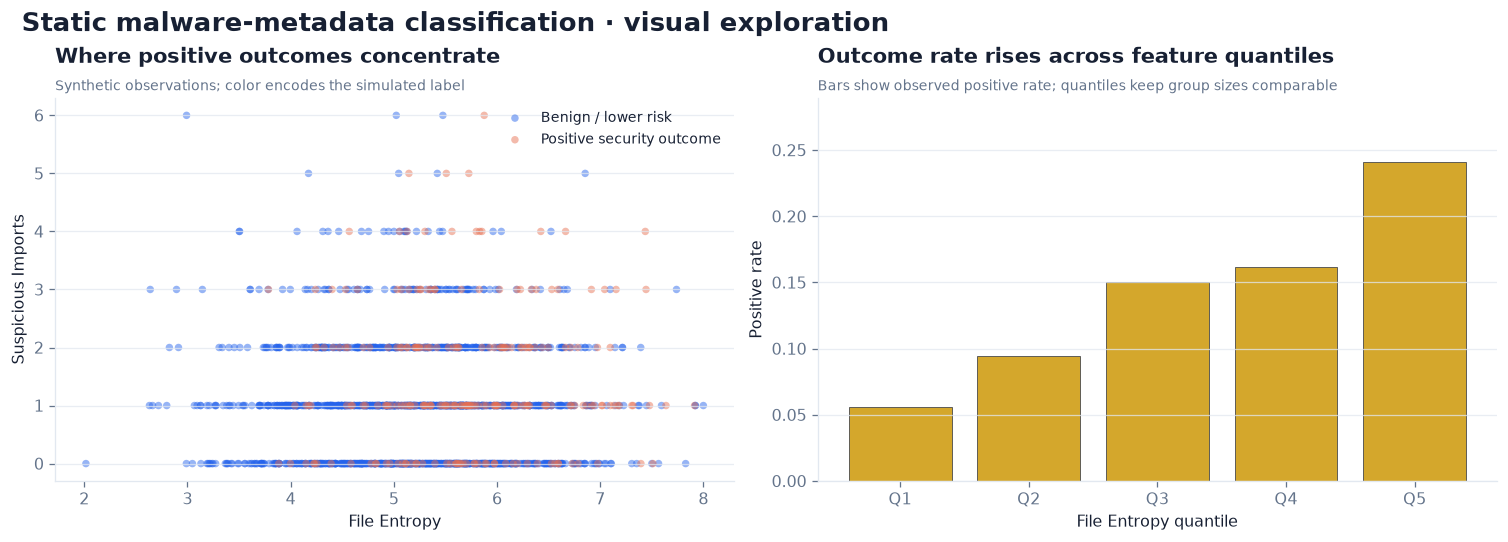

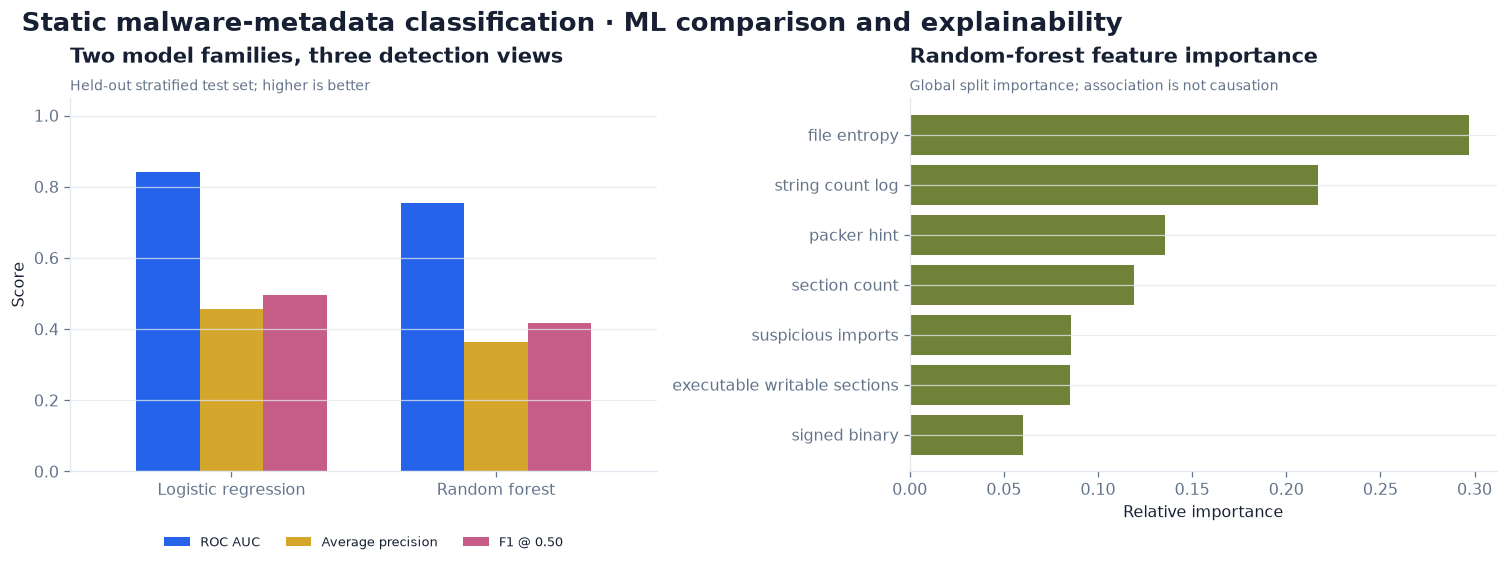

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 42)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def binary_model_comparison(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.28,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows = []
    probabilities = {}
    fitted = {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

model_frame = static_features.copy()
ml_features = model_frame.drop(columns=["malicious"]).select_dtypes(include=[np.number])
ml_labels = model_frame["malicious"].to_numpy(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)
for class_value, color, class_name in [
    (0, PALETTE["blue"], "Benign / lower risk"),
    (1, PALETTE["orange"], "Positive security outcome"),
]:
    subset = model_frame[model_frame["malicious"] == class_value]
    axes[0].scatter(
        subset["file_entropy"], subset["suspicious_imports"],
        s=22, alpha=0.48, color=color, edgecolors="none", label=class_name,
    )
polish_axis(
    axes[0],
    "Where positive outcomes concentrate",
    "Synthetic observations; color encodes the simulated label",
    "File Entropy",
    "Suspicious Imports",
)
axes[0].legend(frameon=False, fontsize=9)

risk_bins = pd.qcut(model_frame["file_entropy"], q=5, duplicates="drop")
rate_by_bin = model_frame.groupby(risk_bins, observed=True)["malicious"].agg(["mean", "size"])
axes[1].bar(
    range(len(rate_by_bin)), rate_by_bin["mean"],
    color=PALETTE["gold"], edgecolor=PALETTE["ink"], linewidth=0.4,
)
axes[1].set_xticks(range(len(rate_by_bin)), [f"Q{index + 1}" for index in range(len(rate_by_bin))])
axes[1].set_ylim(0, max(0.05, rate_by_bin["mean"].max() * 1.2))
polish_axis(
    axes[1],
    "Outcome rate rises across feature quantiles",
    "Bars show observed positive rate; quantiles keep group sizes comparable",
    "File Entropy quantile",
    "Positive rate",
)
fig.suptitle("Static malware-metadata classification · visual exploration", fontsize=16, fontweight="bold", x=0.01, ha="left")

model_comparison, fitted_models, model_probabilities, comparison_labels = binary_model_comparison(
    ml_features, ml_labels
)
best_model_name = model_comparison["average_precision"].idxmax()
best_probability = model_probabilities[best_model_name]
review_count = max(1, int(len(best_probability) * 0.10))
top_positions = np.argsort(best_probability)[-review_count:]
comparison_labels_array = np.asarray(comparison_labels)
base_rate = float(comparison_labels_array.mean())
top_rate = float(comparison_labels_array[top_positions].mean())
top_decile_lift = top_rate / max(base_rate, 1e-9)

forest = fitted_models["Random forest"]
feature_importance = pd.Series(
    forest.feature_importances_, index=ml_features.columns, name="importance"
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
metric_colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["pink"]]
comparison_display = model_comparison.rename(columns={
    "roc_auc": "ROC AUC",
    "average_precision": "Average precision",
    "f1_at_0_5": "F1 @ 0.50",
})
comparison_display.plot(kind="bar", ax=axes[0], color=metric_colors, width=0.72)
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(frameon=False, ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14))
polish_axis(
    axes[0],
    "Two model families, three detection views",
    "Held-out stratified test set; higher is better",
    "",
    "Score",
)

top_importance = feature_importance.head(7).sort_values()
axes[1].barh(top_importance.index.str.replace("_", " "), top_importance.values, color=PALETTE["olive"])
polish_axis(
    axes[1],
    "Random-forest feature importance",
    "Global split importance; association is not causation",
    "Relative importance",
    "",
)
fig.suptitle("Static malware-metadata classification · ML comparison and explainability", fontsize=16, fontweight="bold", x=0.01, ha="left")

print("Model comparison (held-out data):")
print(model_comparison.round(3).to_string())
print("\nAnalyst takeaways:")
print(f"- Best average precision: {best_model_name} ({model_comparison.loc[best_model_name, 'average_precision']:.3f}).")
print(f"- The highest-scored 10% is {top_decile_lift:.1f}× denser in positives than the test-set baseline.")
print(f"- Strongest random-forest driver: {feature_importance.index[0].replace('_', ' ')}.")
print("- Treat these synthetic benchmarks as a workflow example; production thresholds require temporal validation and drift monitoring.")


## Checks


In [5]:
assert static_features["file_entropy"].between(1, 8).all()
assert malware_metrics["f1"] >= 0.45
assert ranked_samples["malicious_probability"].is_monotonic_decreasing
assert malware_importance.iloc[0]["standardized_weight"] > 0
print("Checks passed: bounded metadata, usable synthetic-data F1, sorted risk, and positive risk drivers.")


Checks passed: bounded metadata, usable synthetic-data F1, sorted risk, and positive risk drivers.


## Next Steps

        - Use an approved static-analysis pipeline and never execute unknown samples in this notebook.
- Evaluate family and time-based splits to expose concept drift.
- Combine static signals with sandbox results only in an isolated malware-analysis environment.
